In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pickle
import pandas as pd
import uproot
import awkward as ak
import tabulate as tab
import glob
import h5py
from tqdm import tqdm

from scipy.signal import find_peaks


# How to read raw data files

In [2]:
def read_root_files(filepath, cosmics=False):
    file = uproot.open(filepath)
    print(file.keys())
    analyszer = 'PNSCRPanalyzercosmics' if cosmics else 'PNSCRPanalyzerflashes1'
    evts = uproot.open(f"{filepath}:{analyszer}/Event")
    akw = evts.arrays(filter_name=evts.keys(), library="ak")
    return akw

def get_info(akw, display=False):
    Nevents    = len(akw['waveformsADC'])
    TrigWindow = len(akw['waveformsADC'][0][0])
    Nchannels  = len(akw['waveformsADC'][0])
    maxima = []
    for chID in range(0, Nchannels):
        maxima.append(ak.max( akw['waveformsADC'][:][chID]) )
    if display:
        print(' trigger reccords', Nevents)
        print(' trigger window', TrigWindow)
        print(' number of channels', Nchannels)
        print(' max height', int(np.max(maxima)) )
    return Nevents, TrigWindow, Nchannels, maxima


In [3]:
# path to the file
cernbox = '/Users/emiliebertholet/cernbox/coldbox_data'
directory = f'{cernbox}/anaCRP_files/raw_files'
filename = 'ana_pns_r25036_small_0_7.root'


In [4]:
cosmics = False
if 'cosmics' in filename: cosmics = True
akw = read_root_files(f'{directory}/{filename}', cosmics=cosmics)

['PNSCRPanalyzerflashes1;1', 'PNSCRPanalyzerflashes1/Event;87', 'PNSCRPanalyzerflashes1/Event;86']


In [5]:
_, _, _, _ = get_info(akw, display=True)

 trigger reccords 2324
 trigger window 65600
 number of channels 12
 max height 16383


In [6]:
akw

<Array [{event: 1, evttime: ..., ...}, ...] type='2324 * {event: int32, evt...'>

# File Organization

The file contains many variables corresponding to the readout of different detectors. For the moment, we focus on ```waveformsADC```, which stores the digitized output of the xARAPUCA modules (SiPM-based light detectors).

### Waveform Format

The waveforms are electrical pulses. Because they are digitized, they are recorded as ADC counts vs. time ticks, rather than voltage vs. physical time.

- 1 ADC count corresponds to a specific voltage increment.

- 1 time tick corresponds to a fixed time interval.

In the ColdBox there are several xARAPUCA modules. Each module provides 2 readout channels. At first, we want to look at 1 channel at a time.

The strucutre of the data for one specific channel is an array of arrays:

### Data Structure

For a given channel, the waveform data is stored as a list of arrays, where each array corresponds to one trigger record.

```
[
    [ADC_0, ADC_1, ADC_2, ..., ADC_N],   # trigger record 0
    [ADC_0, ADC_1, ADC_2, ..., ADC_N],   # trigger record 1
    ...
]

```

A trigger record correspond to an acquisition window of a fixed number of time ticks.






In [7]:
raw_wfs = akw['waveformsADC']
raw_wfs

<Array [[[1.7e+03, ..., 1.72e+03], ...], ...] type='2324 * var * var * float32'>

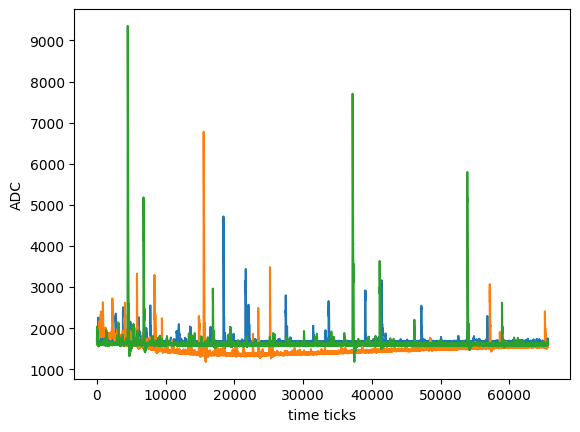

In [8]:
# several triggger records
chID = 0
triggerRecs = [0, 10, 15]
for i in triggerRecs:
    plt.plot(raw_wfs[i][chID])
plt.xlabel('time ticks')
plt.ylabel('ADC');

In [9]:
## check trigger length 
chID = 0
lengths = ak.to_numpy( ak.num(raw_wfs[:, chID]) )
values, counts = np.unique(lengths, return_counts=True)
print(values, counts)
print(counts)

[65536 65600] [  26 2298]
[  26 2298]


In [10]:
len(raw_wfs)

2324

In [ ]:
## TODO: add also the cases where the lenght of the trigger record is smaller

max_evts = len(raw_wfs)
chID = 1

arr = [ak.to_numpy(raw_wfs[i][chID]) for i in range(len(raw_wfs)) if len(ak.to_numpy(raw_wfs[i][chID])) == 65600]
N = len(arr)
print(N)

# np.savez(
#     f"trig_{N}_chID_{chID}.npz",
#     X=arr,
# )

2298


In [11]:
## TODO: plot some trigRecs by channels